# Análisis Exploratorio de Datos (EDA) completo
## Dataset: Tips (propinas en restaurantes)

Este notebook realiza un EDA exhaustivo del dataset **tips** de Seaborn, que contiene información sobre las propinas en un restaurante. Usaremos **NumPy, Pandas, Matplotlib y Seaborn** para explorar y visualizar los datos, aplicando un flujo de trabajo sistemático que podrás replicar en cualquier otro dataset.

In [1]:
# ============================================================
# 1. CONFIGURACIÓN INICIAL
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo y visualización
sns.set_style('whitegrid')
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# ============================================================
# 2. CARGA DEL DATASET
# ============================================================
df = sns.load_dataset('tips')
print('Dataset cargado correctamente')
print(f'Dimensiones: {df.shape}')
df.head()

Dataset cargado correctamente
Dimensiones: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 3. INSPECCIÓN INICIAL Y LIMPIEZA
Conocemos la estructura, tipos de datos y verificamos si hay valores faltantes.

In [3]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


In [5]:
# Verificar valores nulos
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


**Observación:** No hay valores nulos. Sin embargo, vamos a asegurar que las variables categóricas tengan el tipo adecuado.

In [6]:
# Convertir a tipo 'category' las columnas que corresponden
cat_cols = ['sex', 'smoker', 'day', 'time']
for col in cat_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


## 4. ANÁLISIS UNIVARIANTE

### 4.1. Variables numéricas
Seleccionamos las columnas numéricas: total_bill, tip, size.

In [7]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
print('Variables numéricas:', num_cols)

Variables numéricas: ['total_bill', 'tip', 'size']


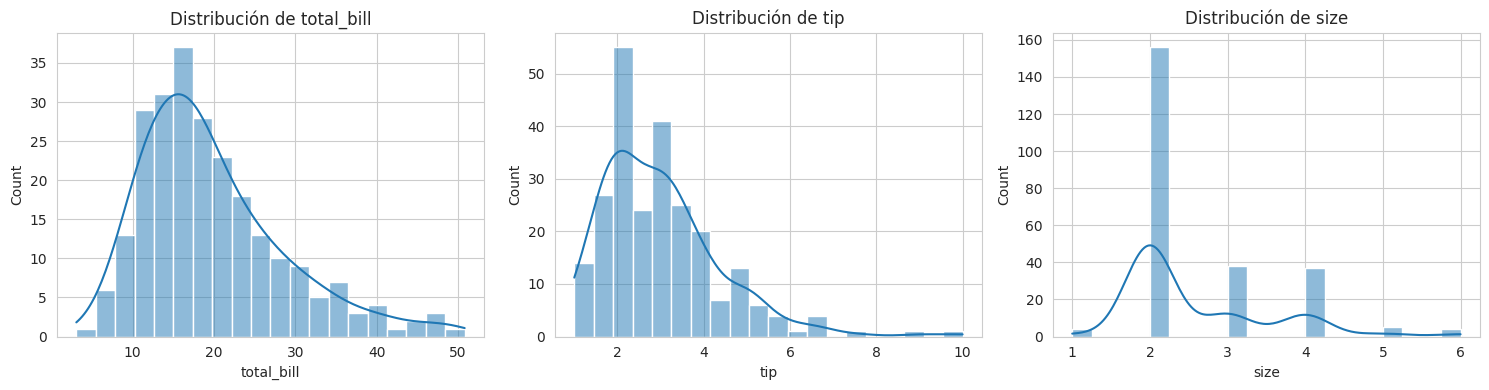

In [8]:
# Histogramas con KDE
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=20)
    axes[i].set_title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

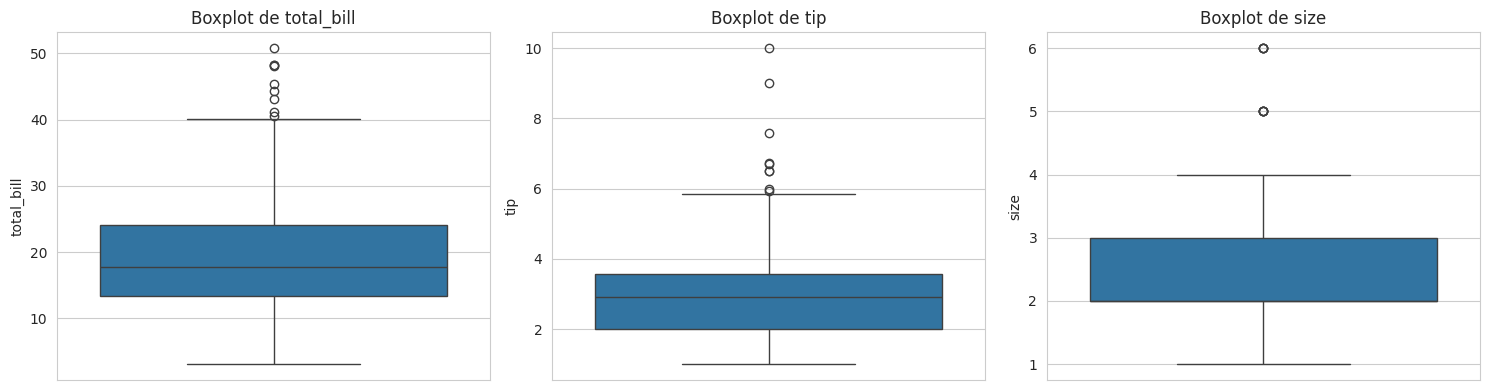

In [9]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

In [10]:
# Estadísticas de forma (asimetría)
for col in num_cols:
    print(f'{col}: skewness = {df[col].skew():.2f}')

total_bill: skewness = 1.13
tip: skewness = 1.47
size: skewness = 1.45


### 4.2. Variables categóricas
Analizamos sex, smoker, day, time.


--- sex ---
sex
Male      157
Female     87
Name: count, dtype: int64
Moda: Male


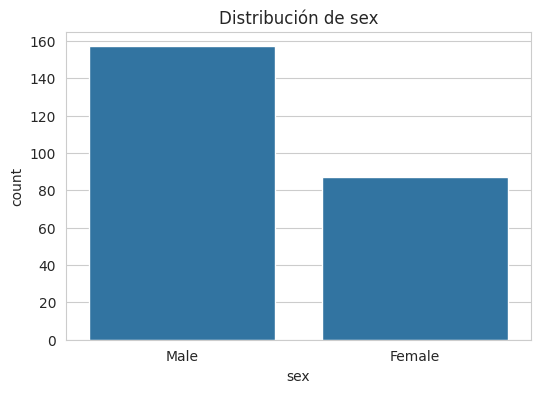


--- smoker ---
smoker
No     151
Yes     93
Name: count, dtype: int64
Moda: No


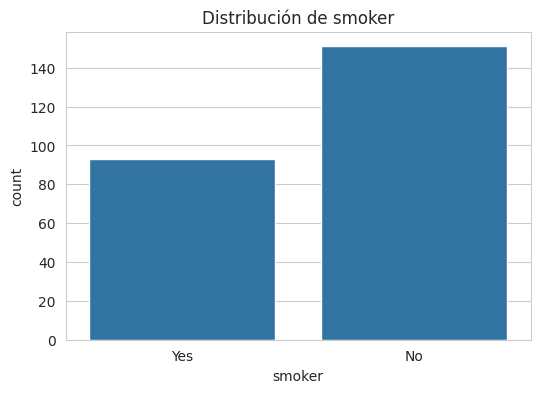


--- day ---
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64
Moda: Sat


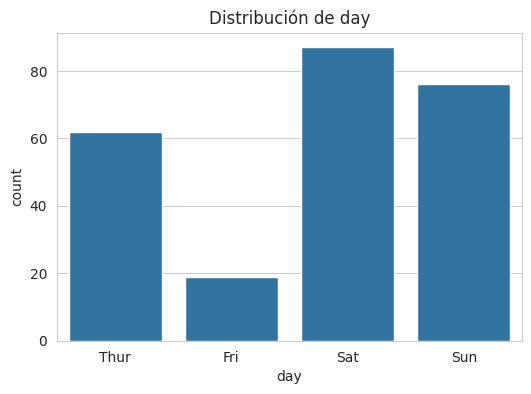


--- time ---
time
Dinner    176
Lunch      68
Name: count, dtype: int64
Moda: Dinner


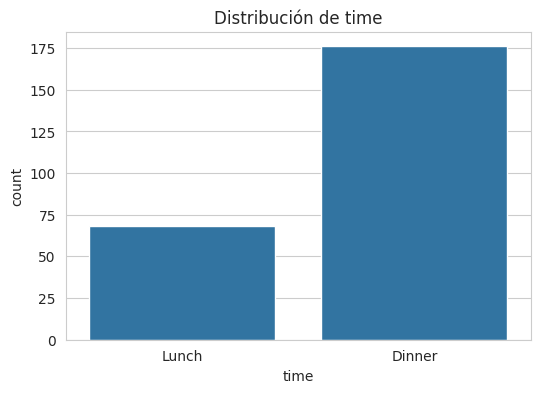

In [11]:
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())
    print(f'Moda: {df[col].mode()[0]}')

    # Gráfico de barras
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribución de {col}')
    plt.show()

## 5. ANÁLISIS BIVARIANTE

### 5.1. Relación entre variables numéricas

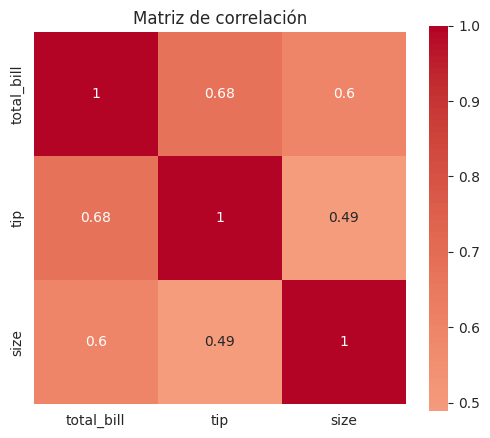

In [12]:
# Matriz de correlación
corr = df[num_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Matriz de correlación')
plt.show()

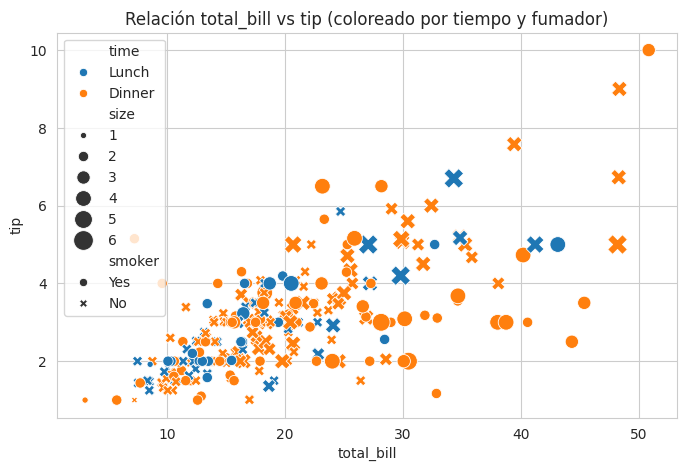

In [13]:
# Scatter plot entre total_bill y tip
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', style='smoker', size='size', sizes=(20,200))
plt.title('Relación total_bill vs tip (coloreado por tiempo y fumador)')
plt.show()

### 5.2. Relación entre numérica y categórica

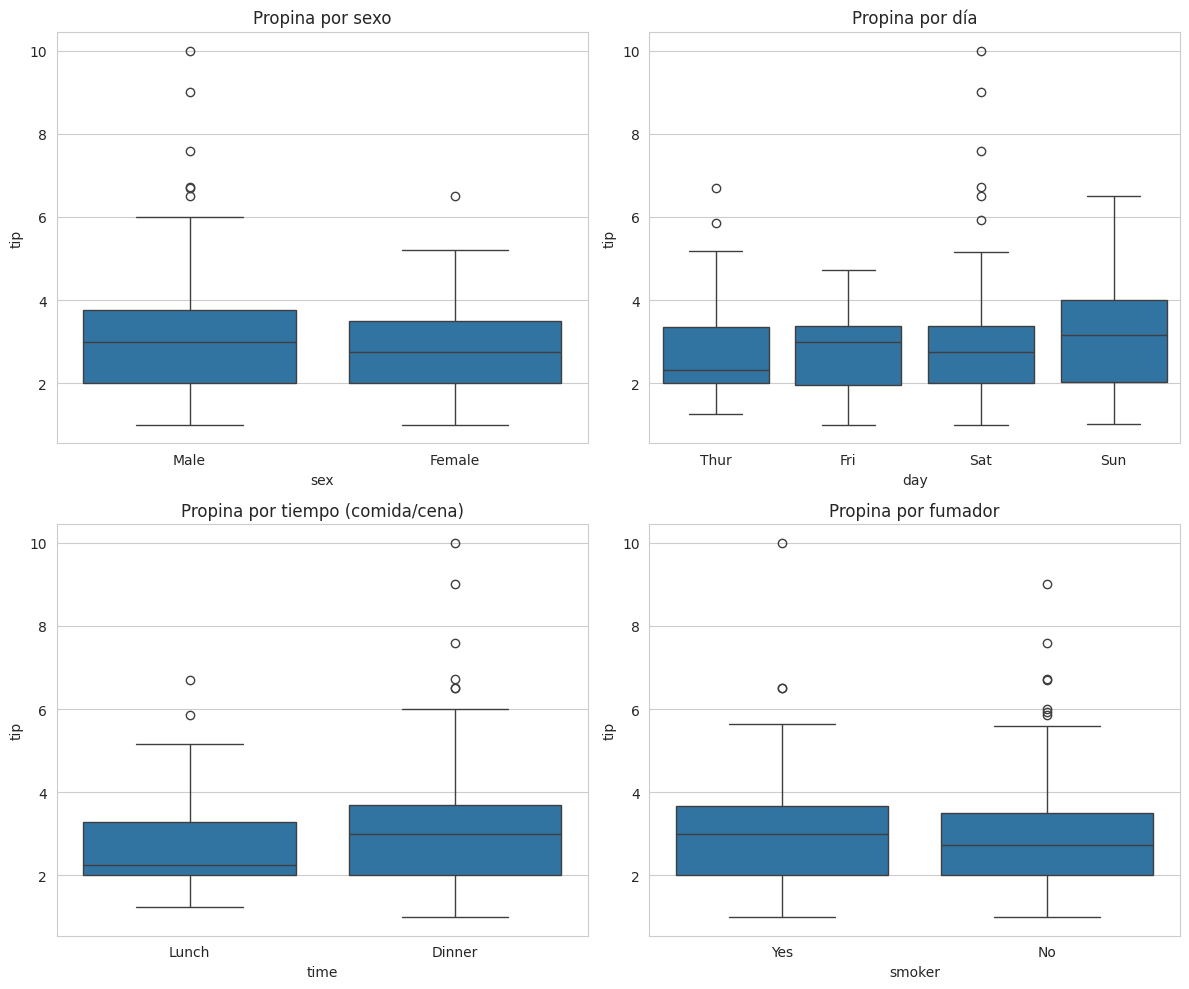

In [14]:
# Boxplots de propina por sexo, día y tiempo
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(data=df, x='sex', y='tip', ax=axes[0,0])
axes[0,0].set_title('Propina por sexo')

sns.boxplot(data=df, x='day', y='tip', ax=axes[0,1])
axes[0,1].set_title('Propina por día')

sns.boxplot(data=df, x='time', y='tip', ax=axes[1,0])
axes[1,0].set_title('Propina por tiempo (comida/cena)')

sns.boxplot(data=df, x='smoker', y='tip', ax=axes[1,1])
axes[1,1].set_title('Propina por fumador')

plt.tight_layout()
plt.show()

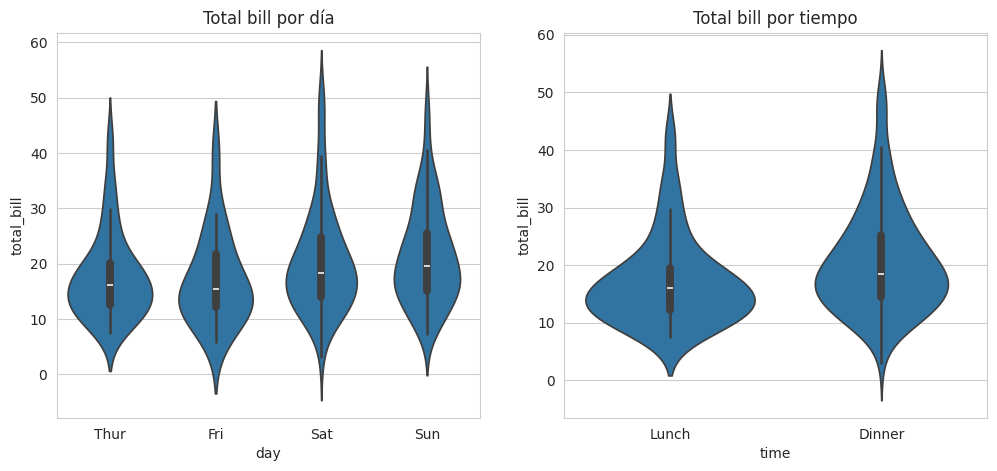

In [15]:
# Violin plots (alternativa más informativa)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.violinplot(data=df, x='day', y='total_bill', ax=axes[0])
axes[0].set_title('Total bill por día')
sns.violinplot(data=df, x='time', y='total_bill', ax=axes[1])
axes[1].set_title('Total bill por tiempo')
plt.show()

### 5.3. Relación entre dos categóricas

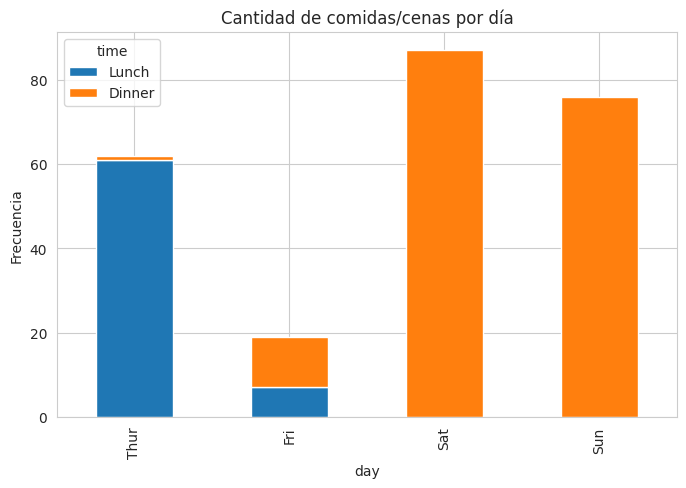

In [16]:
# Tabla de contingencia: día vs tiempo
pd.crosstab(df['day'], df['time'], margins=True)

# Gráfico de barras apiladas
pd.crosstab(df['day'], df['time']).plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Cantidad de comidas/cenas por día')
plt.ylabel('Frecuencia')
plt.show()

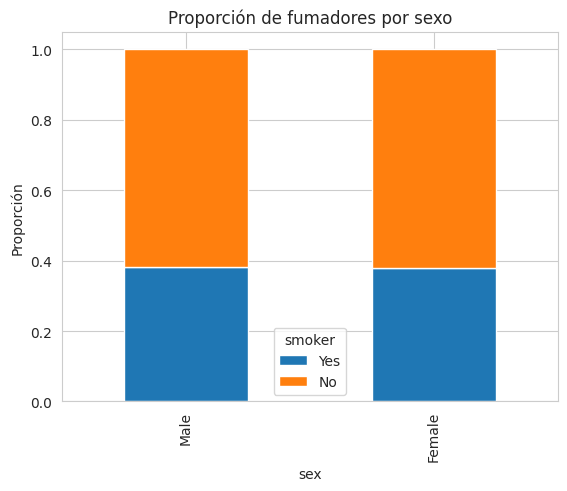

In [17]:
# Otra: sexo vs fumador
pd.crosstab(df['sex'], df['smoker'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Proporción de fumadores por sexo')
plt.ylabel('Proporción')
plt.show()

## 6. DETECCIÓN DE OUTLIERS (MÉTODO IQR)

In [18]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

for col in num_cols:
    outliers, low, up = detect_outliers_iqr(df, col)
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)')
    if len(outliers) > 0:
        print(f'  Límites: [{low:.2f}, {up:.2f}]')
        print(f'  Rango real: [{df[col].min():.2f}, {df[col].max():.2f}]\n')

total_bill: 9 outliers (3.69%)
  Límites: [-2.82, 40.30]
  Rango real: [3.07, 50.81]

tip: 9 outliers (3.69%)
  Límites: [-0.34, 5.91]
  Rango real: [1.00, 10.00]

size: 9 outliers (3.69%)
  Límites: [0.50, 4.50]
  Rango real: [1.00, 6.00]



## 7. FEATURE ENGINEERING (PARA EDA)
Creamos nuevas variables que nos ayuden a entender mejor los datos.

In [19]:
# Porcentaje de propina sobre la cuenta
df['tip_percentage'] = (df['tip'] / df['total_bill']) * 100

# Categoría del tamaño de la mesa (pequeña, mediana, grande)
bins = [0, 2, 4, 6]
labels = ['Pequeña', 'Mediana', 'Grande']
df['size_category'] = pd.cut(df['size'], bins=bins, labels=labels)

# Día ordenado (para gráficos con orden natural)
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
df['day_ordered'] = pd.Categorical(df['day'], categories=day_order, ordered=True)

# Indicador de si la propina es alta (por encima de la mediana)
median_tip = df['tip'].median()
df['high_tip'] = (df['tip'] > median_tip).astype(int)

df[['tip_percentage', 'size_category', 'day_ordered', 'high_tip']].head()

,tip_percentage,size_category,day_ordered,high_tip
0,5.94,Pequeña,Sun,0
1,16.05,Mediana,Sun,0
2,16.66,Mediana,Sun,1
3,13.98,Pequeña,Sun,1
4,14.68,Mediana,Sun,1


### 7.1. Análisis de las nuevas variables

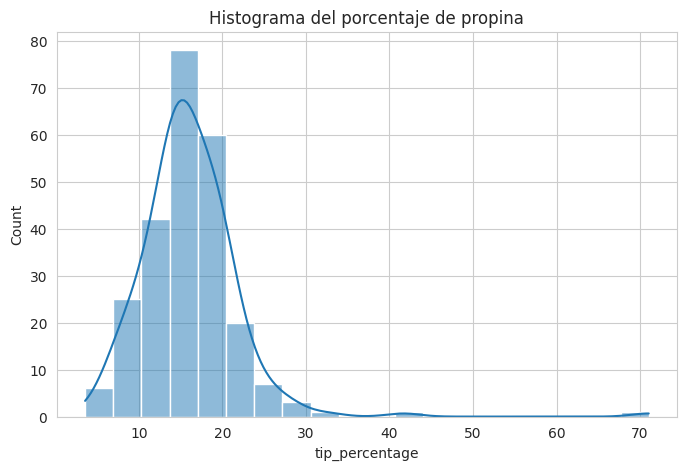

In [20]:
# Distribución del porcentaje de propina
plt.figure(figsize=(8,5))
sns.histplot(df['tip_percentage'], bins=20, kde=True)
plt.title('Histograma del porcentaje de propina')
plt.show()

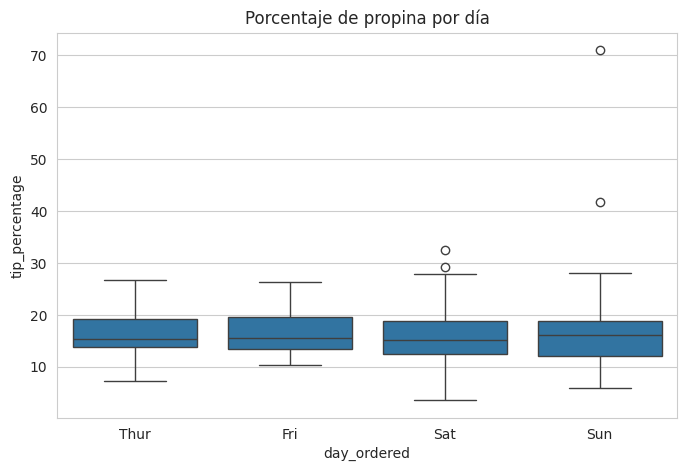

In [21]:
# Porcentaje de propina por día (ordenado)
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='day_ordered', y='tip_percentage')
plt.title('Porcentaje de propina por día')
plt.show()

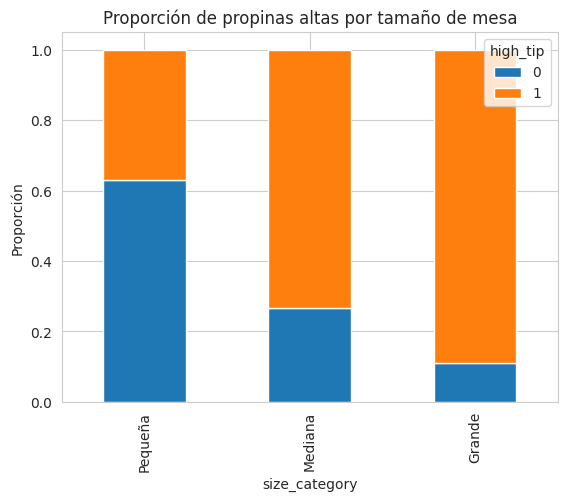

In [22]:
# Proporción de propinas altas por tamaño de mesa
pd.crosstab(df['size_category'], df['high_tip'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Proporción de propinas altas por tamaño de mesa')
plt.ylabel('Proporción')
plt.show()

## 8. VISUALIZACIONES AVANZADAS

### 8.1. FacetGrid: múltiples condicionamientos

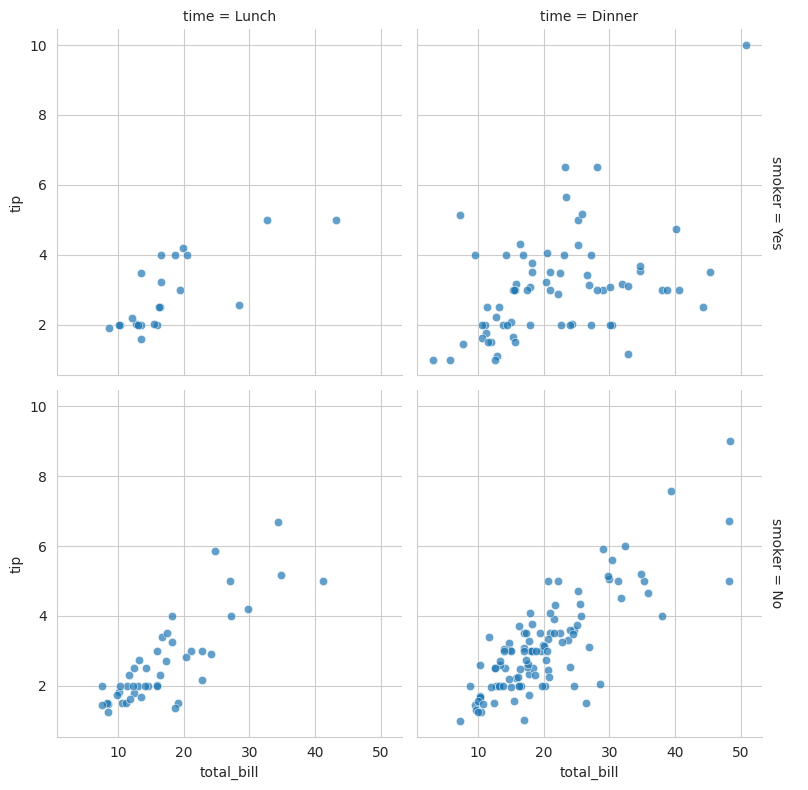

In [23]:
g = sns.FacetGrid(df, col='time', row='smoker', margin_titles=True, height=4)
g.map(sns.scatterplot, 'total_bill', 'tip', alpha=0.7)
g.add_legend()
plt.show()

### 8.2. Pairplot con variables seleccionadas

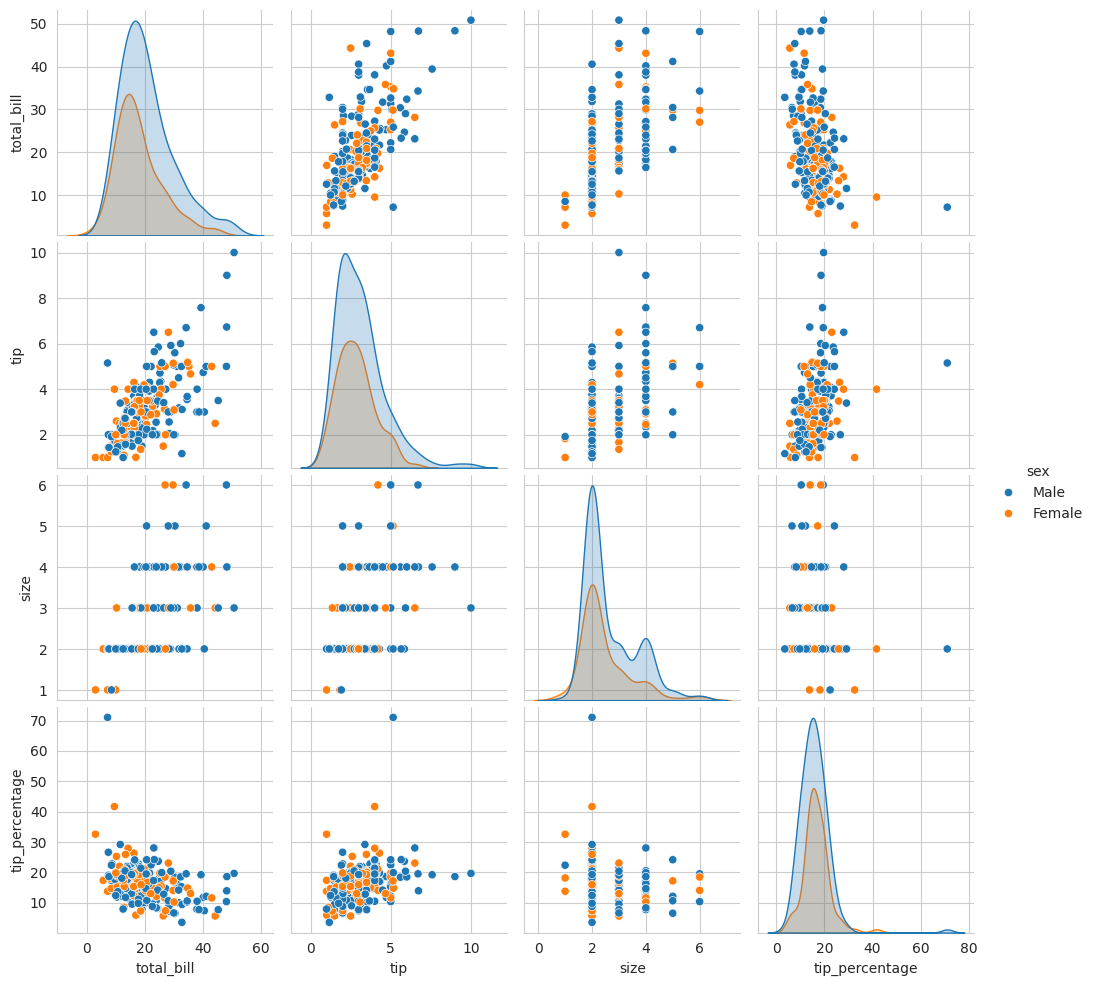

In [24]:
sns.pairplot(df[['total_bill', 'tip', 'size', 'tip_percentage', 'sex', 'day']], hue='sex', diag_kind='kde')
plt.show()

### 8.3. Jointplot con regresión

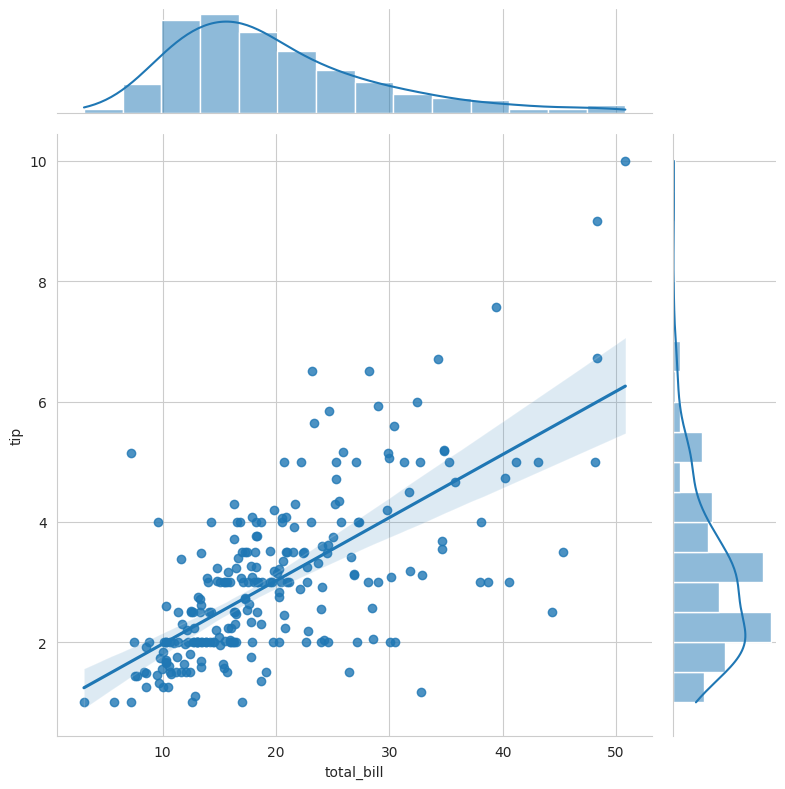

In [25]:
sns.jointplot(data=df, x='total_bill', y='tip', kind='reg', height=8)
plt.show()

### 8.4. Heatmap de correlación con nuevas variables

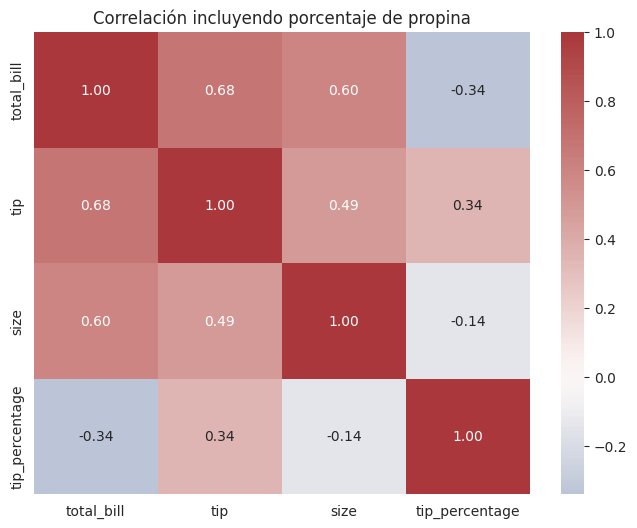

In [26]:
new_numeric = ['tip_percentage']
all_numeric = num_cols + new_numeric
plt.figure(figsize=(8,6))
sns.heatmap(df[all_numeric].corr(), annot=True, cmap='vlag', center=0, fmt='.2f')
plt.title('Correlación incluyendo porcentaje de propina')
plt.show()

## 9. CONCLUSIONES

A lo largo de este notebook hemos aplicado un flujo completo de EDA:
- Carga e inspección de datos
- Limpieza y tipificación de variables
- Análisis univariante con histogramas, boxplots y countplots
- Análisis bivariante con scatter plots, boxplots por categorías, matrices de correlación, tablas de contingencia
- Detección de outliers mediante IQR
- Creación de nuevas características (feature engineering) para enriquecer el análisis
- Visualizaciones avanzadas con FacetGrid, pairplot, jointplot y heatmaps

Este flujo es sistemático y puede replicarse en cualquier dataset. La clave es entender las relaciones entre variables y generar hipótesis que luego podrán ser validadas con modelos predictivos.